In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

data = pd.read_csv(r'C:\Users\ashionye.aninze\Documents\synthetic-data-rough-note\data\artificial_hes_ae_202302_v1_sample\artificial_hes_ae_0708.csv')

C:\Users\ashionye.aninze\AppData\Local\Temp\ipykernel_22084\3500920140.py:7: DtypeWarning: Columns (129,141) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(r'C:\Users\ashionye.aninze\Documents\synthetic-data-rough-note\data\artificial_hes_ae_202302_v1_sample\artificial_hes_ae_0708.csv')


In [2]:
data.head()

,FYEAR,PARTYEAR,PSEUDO_HESID,AEKEY,AEKEY_FLAG,AEARRIVALMODE,AEATTEND_EXC_PLANNED,AEATTENDCAT,AEATTENDDISP,AEDEPTTYPE,...,LSOA11,MSOA11,PROVDIST,PROVDIST_FLAG,NER_GP_PRACTICE,NER_RESIDENCE,NER_TREATMENT,SITETRET,SITEDIST,SITEDIST_FLAG
0,708,200799,TESTLMgmxx4BW0MY95QVCCDpQc0pOIVW,502918283753,1,2,0,1,3,99,...,E01007065,E02001802,0.26,5.0,NaN,NaN,NaN,NaN,NaN,NaN
1,708,200799,TEST1bkwgyU7co8ESC06q2wOfrxj3UA0,419366440791,1,2,1,2,1,99,...,E01006200,E02004210,3.89,3.0,NaN,NaN,NaN,NaN,NaN,NaN
2,708,200799,TEST1bkwgyU7co8ESC06q2wOfrxj3UA0,846671915575,1,2,1,1,3,99,...,E01001320,E02001950,2.56,3.0,NaN,NaN,NaN,NaN,NaN,NaN
3,708,200799,TESTQAIuSanLgpC0viam05LCEml702op,479306996883,1,2,1,1,1,99,...,E01011458,E02000453,1.31,5.0,NaN,NaN,NaN,NaN,NaN,NaN
4,708,200799,TEST6FXSKBClkLES7fu5A8U3t5b5mo7l,725682360706,1,2,1,1,2,99,...,E01022644,E02005884,1.58,3.0,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
data.describe()

,FYEAR,PARTYEAR,AEKEY,AEKEY_FLAG,AEARRIVALMODE,AEATTEND_EXC_PLANNED,AEATTENDCAT,AEATTENDDISP,AEDEPTTYPE,AEINCLOCTYPE,...,TRETDUR,TRETTIME,PROVDIST,PROVDIST_FLAG,NER_GP_PRACTICE,NER_RESIDENCE,NER_TREATMENT,SITETRET,SITEDIST,SITEDIST_FLAG
count,10000.0,10000.0,1.000000e+04,10000.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,8361.000000,8521.00000,0.0,0.0,0.0,0.0,0.0,0.0
mean,708.0,200799.0,5.031052e+11,1.0,1.899800,0.964800,1.133000,3.720400,98.834400,49.583800,...,81.453000,1778.402700,10.932365,3.83746,NaN,NaN,NaN,NaN,NaN,NaN
std,0.0,0.0,2.879785e+11,0.0,1.082163,0.184294,0.746704,6.276987,4.013351,37.610121,...,123.576896,1180.112254,22.649437,0.98676,NaN,NaN,NaN,NaN,NaN,NaN
min,708.0,200799.0,9.368645e+07,1.0,1.000000,0.000000,1.000000,1.000000,1.000000,10.000000,...,0.000000,0.000000,0.060000,3.00000,NaN,NaN,NaN,NaN,NaN,NaN
25%,708.0,200799.0,2.566478e+11,1.0,2.000000,1.000000,1.000000,2.000000,99.000000,10.000000,...,20.000000,1043.750000,2.740000,3.00000,NaN,NaN,NaN,NaN,NaN,NaN
50%,708.0,200799.0,5.042284e+11,1.0,2.000000,1.000000,1.000000,3.000000,99.000000,50.000000,...,50.000000,1544.500000,5.130000,3.00000,NaN,NaN,NaN,NaN,NaN,NaN
75%,708.0,200799.0,7.504777e+11,1.0,2.000000,1.000000,1.000000,3.000000,99.000000,91.000000,...,95.000000,2130.000000,11.060000,5.00000,NaN,NaN,NaN,NaN,NaN,NaN
max,708.0,200799.0,9.999187e+11,1.0,9.000000,1.000000,9.000000,99.000000,99.000000,99.000000,...,948.000000,4000.000000,296.310000,5.00000,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 165 entries, FYEAR to SITEDIST_FLAG
dtypes: float64(102), int64(24), object(39)
memory usage: 12.6+ MB


In [5]:
# Creating dataset that has only columns that are needed for analysis
rel_data = data[['ARRIVALAGE', 'SEX', 'DIAG3_01', 'TREAT3_01','AEATTENDDISP', 'AEARRIVALMODE' ]]

# Replace all NaN values with 0
rel_data = rel_data.fillna(0)

# Creating a copy of the dataset for encoding
encoded = rel_data.copy()

# Encoding all variables
label_encoders = {}
for column in encoded.columns:
    le = LabelEncoder()
    encoded[column] = le.fit_transform(encoded[column].astype(str))
    label_encoders[column] = le
    
    
encoded.head()


,ARRIVALAGE,SEX,DIAG3_01,TREAT3_01,AEATTENDDISP,AEARRIVALMODE
0,1,1,9,42,7,1
1,23,2,90,0,0,1
2,40,2,7,1,7,1
3,37,1,27,1,0,1
4,60,1,0,6,6,1


In [6]:
rel_data.head(30)

,ARRIVALAGE,SEX,DIAG3_01,TREAT3_01,AEATTENDDISP,AEARRIVALMODE
0,1.0,1,040,222,3,2
1,28.0,2,38,0,1,2
2,43.0,2,03,01,3,2
3,40.0,1,101,01,1,2
4,61.0,1,0,02,2,2
5,7006.0,1,0,27,1,1
6,42.0,1,03,0,1,1
7,74.0,1,023,0,3,2
8,81.0,1,38,0,3,2
9,35.0,1,02,222,3,2


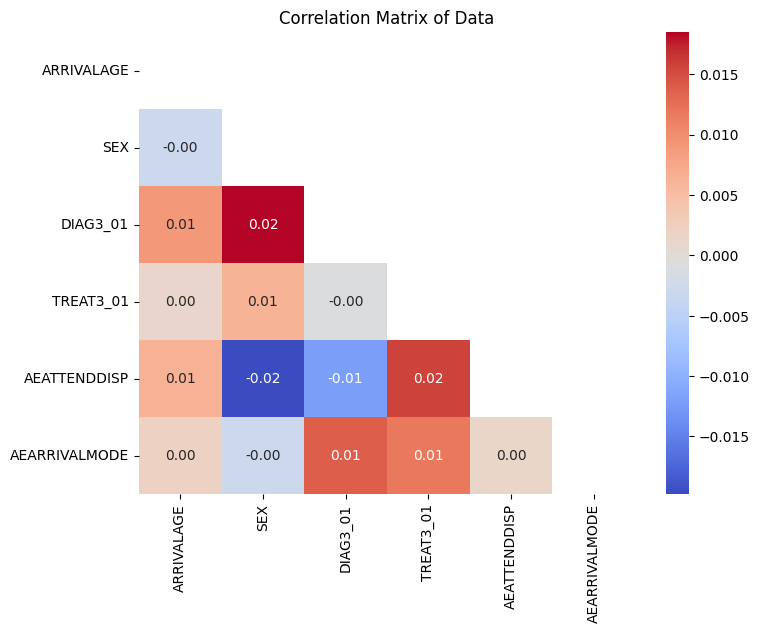

In [7]:
correlation_matrix = encoded.corr(numeric_only=True)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", mask=mask)
plt.title('Correlation Matrix of Data')
plt.show()

In [8]:
def ambulance_rule(data):
    # Rule: If ARRIVALAGE is 1 (Brought in by an ambulance), then set AEATTENDDISP to 1 (hospital bed)
    data.loc[data['AEARRIVALMODE'] == 1, 'AEATTENDDISP'] = 1
    return data

ambulance_rule(rel_data)

,ARRIVALAGE,SEX,DIAG3_01,TREAT3_01,AEATTENDDISP,AEARRIVALMODE
0,1.0,1,040,222,3,2
1,28.0,2,38,0,1,2
2,43.0,2,03,01,3,2
3,40.0,1,101,01,1,2
4,61.0,1,0,02,2,2
...,...,...,...,...,...,...
9995,49.0,1,38,0,1,2
9996,55.0,1,021,222,1,1
9997,22.0,1,263,22,1,1
9998,58.0,1,0,0,5,2


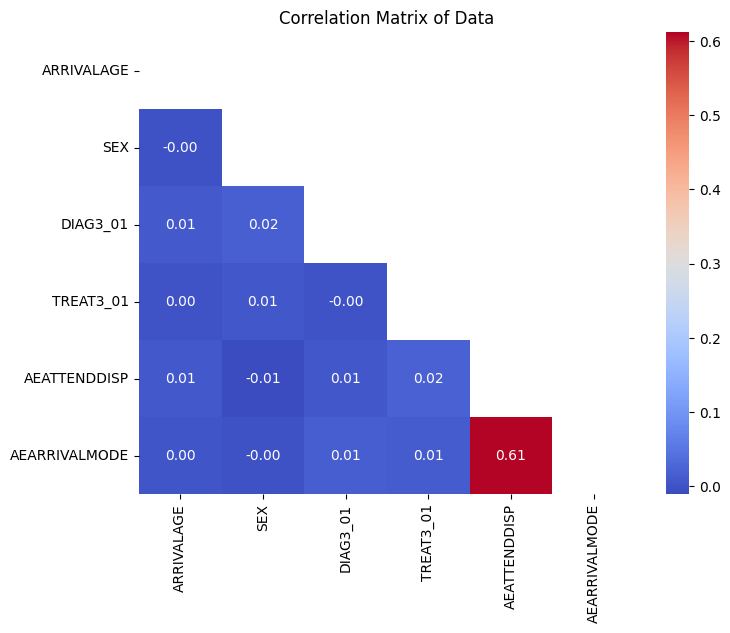

In [13]:
label_encoders = {}
for column in rel_data.columns:
    le = LabelEncoder()
    rel_data[column] = le.fit_transform(rel_data[column].astype(str))
    label_encoders[column] = le

correlation_matrix = rel_data.corr(numeric_only=True)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", mask=mask)
plt.title('Correlation Matrix of Data')
plt.show()

In [10]:
def generate_synthetic_column(df, source_column, target_column):
    """
    Generates a new synthetic column based on the probabilistic relationship
    between a source column and a target column.
    
    Args:
        df (pd.DataFrame): The DataFrame containing the data.
        source_column (str): The name of the source column. This is the column used to find probabilistic relationships.
        target_column (str): The name of the target column.

    Returns:
        pd.DataFrame: The DataFrame with the new synthetic column added.
        
    """
    temp_df = df.copy()

    # Handles missing values
    temp_df[source_column] = temp_df[source_column].fillna('Unknown')
    temp_df[target_column] = temp_df[target_column].fillna('Unknown')
    
    prob_table = pd.crosstab(temp_df[source_column], temp_df[target_column])
    prob_table = prob_table.div(prob_table.sum(axis=1), axis=0)
    
    
    def inject_rel(row):
        ''' This function injects a relationship into a
        single row based on the provided probability table. '''

        source_value = row[source_column]
        
        if source_value in prob_table.index:
            targets = prob_table.columns # Gets the target codes
            probabilities = prob_table.loc[source_value]
            probabilities = probabilities / probabilities.sum()
            return np.random.choice(targets, p=probabilities)
        else:
            overall = prob_table.sum(axis=0) / prob_table.sum().sum()
            return np.random.choice(prob_table.columns, p=overall)


    return temp_df.apply(inject_rel, axis=1)

synthetic = rel_data.copy()

synthetic['SYNSEX'] = generate_synthetic_column(synthetic, 'DIAG3_01', 'SEX')
synthetic['SYNDIAG'] = generate_synthetic_column(synthetic, 'SEX', 'DIAG3_01')

synthetic


,ARRIVALAGE,SEX,DIAG3_01,TREAT3_01,AEATTENDDISP,AEARRIVALMODE,SYNSEX,SYNDIAG
0,1.0,1,040,222,3,2,1,01
1,28.0,2,38,0,1,2,2,39
2,43.0,2,03,01,3,2,1,0
3,40.0,1,101,01,1,2,1,0
4,61.0,1,0,02,2,2,1,38
...,...,...,...,...,...,...,...,...
9995,49.0,1,38,0,1,2,2,38
9996,55.0,1,021,222,1,1,1,0
9997,22.0,1,263,22,1,1,2,0
9998,58.0,1,0,0,5,2,1,18


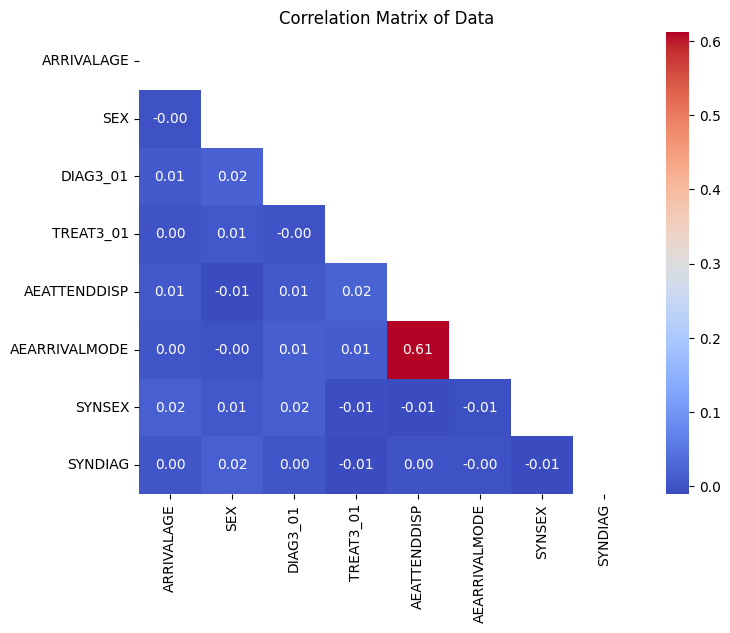

In [11]:
label_encoders = {}
for column in synthetic.columns:
    le = LabelEncoder()
    synthetic[column] = le.fit_transform(synthetic[column].astype(str))
    label_encoders[column] = le

correlation_matrix = synthetic.corr(numeric_only=True)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", mask=mask)
plt.title('Correlation Matrix of Data')
plt.show()